In [2]:
from langgraph.graph import START, MessagesState, StateGraph
from langgraph.checkpoint.memory import InMemorySaver
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint

from dotenv import load_dotenv
from langchain.messages import RemoveMessage

In [3]:
load_dotenv()

True

In [4]:
# define the hugging face endpoint
llm = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct",
    task="text-generation",
    max_new_tokens=2048,
)

# define the model
model = ChatHuggingFace(llm=llm)

In [5]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [6]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [7]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [8]:
graph = builder.compile(checkpointer=InMemorySaver())

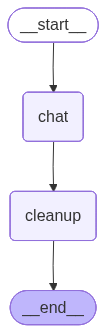

In [9]:
graph

In [10]:
config = {"configurable": {"thread_id": "t1"}}

In [11]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Nitish"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='19744cfe-981b-4d46-8645-59f204e03fe7'),
  AIMessage(content='Langchain is a framework that focuses on building and deploying large language models (LLMs) in a way that enhances their utility and performance. It provides tools and techniques to manage the complexity of working with these models, especially in applications that require real-time interaction and integration with other systems.\n\n### Key Features and Aspects of Langchain\n\n1. **Large Language Model Integration**:\n   - **Integration with Models**: Langchain can work with various large language models, including those from Alibaba Cloud and other sources. It provides a consistent interface for interacting with these models.\n   - **Model Management**: It helps manage the lifecycle of models, including loading, saving, and fine-tuning.\n\n2. **Real-Time Interaction**:\n   - **Inference**: Langchain optimizes the inferenc

In [12]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
